# Idea grafting replicates in biomedical MeSH concepts: G4 PPML demo

**Artifact:** `art_XGdzjWgi-a88` (experiment, iteration 4): a one-look MeSH replication of the D2 *host-entry grafting* test.

**The question.** A scientific concept *c* originates in subfield *o* and later **enters** a new host subfield *d* in year *e*. Does the entry attract more **newcomer uptake**? Uptake is measured as `Y_strict`: papers in *d* over the next window (W2) by authors disjoint from the entry authors. The test asks whether uptake is higher when the concept arrives *anchored* in partners that are already native to the host. The anchoring measure is `A_cont`, the continuous nativeness share of the concept's W1 partner tags in *d*. The model also controls for `CT`, the share of partners that are co-transferred with the concept.

**What the full pipeline did** (`method.py` runs stages `gates → load → coverage → events → nativeness → features → freeze → outcomes → models → report`):
it built 2,267 host-entry events for 187 MeSH biomedical concepts from OpenAlex/PubMed. It fetched 2,509 author nativeness profiles, froze a pre-registered spec (sha256 `b7cdabf8…`), and then fit Poisson pseudo-maximum-likelihood (PPML) models with high-dimensional fixed effects:

| row | fixed effects | full-run IRR per SD of `A_cont` |
|---|---|---|
| **R2** (co-primary, decisive) | concept + e + d | **1.233 [1.117, 1.361]**, Holm p 9.7e-05, wild p 0.001 |
| R1 (primary) | concept×e + d×e | 1.324 [1.098, 1.598], p 0.0037 |

Verdict: **REPLICATED** (reading GRAFTING in both FE specs).

**What this notebook runs.** The stages up to `outcomes` need paid OpenAlex calls and several upstream datasets, so they cannot run in Colab. This notebook reruns the **inferential core** instead: stage 10 (`models_mesh.run`: the PPML rows, wild-cluster score bootstrap, Holm, outcome-shuffle placebo, main-vs-MeSH comparison and G4 verdict) and the out-of-fold predictive check from stage 11 (`report.method_out`). It runs the original, unchanged code on a curated subset of **97 events from 10 concepts**, taken from the artifact's `full_method_out.json` event table.

> On the complete 2,249-event table the same cells reproduce R2 exactly (IRR/SD 1.2330, N 2,171, G 160, Holm p 9.7e-05). At 97 events and 10 concept clusters the estimates are noisy and R1 is not estimable, so treat the demo numbers as a walk-through of the method, not as evidence. The last cell sets them against the full-run values.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')

In [2]:
# --- original import block (method.py) ---
from __future__ import annotations

import argparse
import json
import os
import sys
import time
from pathlib import Path

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # small dense problems; avoids BLAS oversubscription in the spawn workers

from loguru import logger  # noqa: E402

# --- imports of the stage modules used below (src/models_mesh.py, src/report.py, vendor/ppml.py, vendor/models.py) ---
import warnings

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt

# notebook additions: namespaces that stand in for the vendored modules `ppml` / `models`, and logging to stdout
from types import SimpleNamespace
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-4/experiment-9/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
META = data["metadata"]
EXAMPLES = data["datasets"][0]["examples"]
print(f"{len(EXAMPLES)} host-entry events, {META['demo_subset']['n_concepts']} concepts")
print("selection rule:", META["demo_subset"]["rule"])
print("full-run verdict:", META["g4_verdict"], "| R2 IRR/SD", round(META["R2_irr_per_sd_A_cont"], 4), META["R2_ci95"])

97 host-entry events, 10 concepts
selection rule: concepts with 8-12 events and >= 3 events with Y_strict > 0; alternating Life-Sciences / Health-Sciences majority-host concepts, highest positive share first; whole concepts; <= 100 events
full-run verdict: REPLICATED | R2 IRR/SD 1.233 [1.1167392468870916, 1.3613286495308963]


## Configuration

All tunable parameters are set here. The values are the **original pre-registered values** from the frozen `mesh_spec.json`, noted in each comment. On the demo subset they run in well under a minute. `N_BINS` only affects the plot. The PPML fits themselves use the original tolerances (`maxit=500, tol=1e-12`).

In [5]:
WILD_REPS_R1R2 = 999    # wild cluster score-bootstrap draws for R1 / R2           (original: 999)
WILD_REPS_OTHER = 499   # wild bootstrap draws for R3, R4, S2, S3                  (original: 499)
OUTCOME_SHUFFLES = 40   # within-concept outcome-shuffle placebo refits of R2      (original: 40, spec_placebo.outcome_shuffles)
OOF_FOLDS = 5           # grouped-by-concept folds for the out-of-fold check      (original: 5)
DEV_BOOT = 1000         # concept bootstrap draws for the OOF deviance-gain CI    (original: 1000)
N_BINS = 5              # A_cont quantile bins in the binned-uptake plot          (original F2 figure: 10, on 2,267 events)

## Shared constants (`src/common.py`) and the frozen spec

`SEED` and the iteration-3 reference estimates from the main (non-MeSH) screen are copied unchanged from `src/common.py`. The MeSH estimate is compared against them. The control lists come from the frozen `mesh_spec.json`, which ships inside the data file.

In [6]:
SEED = 20260929

# iteration-3 targets (exp_7 results/d2_models.json, d2_robustness.csv)
MAIN_COPRIMARY = {"b_A": 4.739105939721475, "se_A": 1.0102888770711833, "irr_sd": 1.300076888024346,
                  "ci": [1.1639421314281162, 1.452133975682496], "N": 1544, "G": 140}
MAIN_PRIMARY = {"b_A": 5.952633617485952, "irr_sd": 1.385942489788976, "N": 452, "G": 77}
MAIN_NONPHYS = {"b_A": 4.686456999087919, "se_A": 1.354122141289332, "irr_sd": 1.290186634471277,
                "ci": [1.112923630330427, 1.495683536950425], "N": 692, "G": 52,
                "source": "exp_7 results/d2_robustness.csv 'stratum other (descriptive)', secondary FE"}
MAIN_PHYS = {"irr_sd": 0.9516637634583498, "ci": [0.7743171600115374, 1.272165287569658], "N": 248, "G": 50,
             "source": "exp_7 results/d2_robustness.csv 'stratum Physics/Astro (descriptive)', secondary FE"}

# frozen spec (results/mesh_spec.json -> "models") — shipped inside the data file
spec = {"models": META["spec_models"], "placebo": META["spec_placebo"], "prediction": META["spec_prediction"]}
print(json.dumps(spec["models"]["secondary_controls"]))

["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share", "abstract_share", "mom_d", "log_centrality", "log_W1"]


## The estimator: vendored PPML with high-dimensional fixed effects (`vendor/ppml.py`, unchanged)

This is the Poisson pseudo-maximum-likelihood estimator from the iteration-3 D2 screen (exp_7). It was vendored byte-for-byte, and `SHA256SUMS` in the artifact covers it.
* `_prune` iteratively drops singleton FE levels and FE levels whose outcomes are all zero (separation).
* `_demean` projects out the FE space exactly, using a sparse LU factorisation of D'WD.
* `fit` runs IRLS and then computes cluster-robust CRV1 standard errors by concept, with pyfixest's small-sample factor.
* `wild_score_test` is the Kline-Santos wild-cluster (Rademacher) score bootstrap with H0 imposed.

In [7]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


def wild_score_test(y, X_restricted, x2, fes, offset, cluster, rng, reps: int = 199) -> float | None:
    """Kline-Santos wild cluster (Rademacher) score bootstrap for H0: coefficient on x2 = 0."""
    r = fit(y, X_restricted, fes, offset, cluster)
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fes_k = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    Xall = np.column_stack([x2[keep], X_restricted[keep]])
    D = _demean(Xall, mu, fes_k)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    s = np.bincount(r["cl"], weights=x2r * (r["y"] - mu))
    if len(s) < 2 or (s ** 2).sum() == 0:
        return None
    T = s.sum() ** 2 / (s ** 2).sum()
    eps = rng.choice([-1.0, 1.0], size=(reps, len(s)))
    Ts = (eps @ s) ** 2 / (s ** 2).sum()
    return float((1 + (Ts >= T).sum()) / (reps + 1))


# notebook addition: the stage code calls these as `ppml.fit` / `ppml.wild_score_test`
ppml = SimpleNamespace(fit=fit, wild_score_test=wild_score_test, _demean=_demean, _prune=_prune)

## Model wrapper and decision rule (`vendor/models.py`, unchanged)

`fit_one` wraps `ppml.fit` and reports each coefficient as an **incidence-rate ratio per SD** of the regressor on the retained sample, with a t(G−1) 95% CI. The four pre-declared FE layouts are in `FE_SPECS`:
* **primary / R1:** concept×e + d×e
* **secondary / R2:** concept + e + d
* **R3:** concept + d×e
* **R4:** concept×2-year + d×e

`decide` applies the pre-registered reading: GRAFTING / TOOLKIT / BOTH / NEITHER, from Holm-adjusted CRV1 p values over {`A_cont`, `CT`}.

In [8]:
A_VAR = "A_cont"  # primary anchoring measure after the pre-declared nativeness fallback (deviations.md #1)
CT_VAR = "CT"
EVENT_CONTROLS = ["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share",
                  "abstract_share"]
SECONDARY_EXTRA = ["mom_d", "log_centrality", "log_W1"]

FE_SPECS = {"primary": ["cxe", "dxe"], "secondary": ["cfe", "efe", "dfe"],
            "coarse_cx2y": ["cx2", "dxe"],  # pre-declared coarsening: concept x 2-year entry bin + d x e
            "c_plus_dxe": ["cfe", "dxe"]}   # pre-declared alternative: concept + d x e


def fe_arrays(s: pd.DataFrame, spec: str) -> list[np.ndarray]:
    return [s[c].to_numpy() for c in FE_SPECS[spec]]


def fit_one(s: pd.DataFrame, y: str, xvars: list[str], spec: str = "primary", wild: bool = False,
            wild_vars: tuple = (), rng=None) -> dict | None:
    X = s[xvars].to_numpy(float)
    fes = fe_arrays(s, spec)
    yv = s[y].to_numpy(float)
    r = ppml.fit(yv, X, fes, s.offset.to_numpy(), s.concept_id.to_numpy(), maxit=500, tol=1e-12)
    if r is None:
        return None
    keep = r["keep"]
    G = r["G"]
    out = {"spec": spec, "y": y, "x": xvars, "n_input": int(len(s)), "n_retained": int(r["n"]), "G": int(G),
           "retained_share": float(r["n"] / len(s)), "coef": {}, "se": {}, "p": {}, "irr_sd": {}, "irr_01": {},
           "ci_irr_sd": {}, "sd_retained": {}}
    # singleton / separation accounting for the first FE dimension
    cells = pd.Series(fes[0]).value_counts()
    out["n_nonsingleton_fe0_cells"] = int((cells >= 2).sum())
    out["n_fe0_cells"] = int(len(cells))
    out["events_in_nonsingleton_fe0_cells"] = int(cells[cells >= 2].sum())
    tq = stats.t.ppf(0.975, G - 1)
    for i, v in enumerate(xvars):
        b, se = float(r["coef"][i]), float(r["se"][i])
        sd = float(s.loc[keep, v].std())
        tstat = b / se if se > 0 else np.nan
        out["coef"][v], out["se"][v] = b, se
        out["p"][v] = float(2 * stats.t.sf(abs(tstat), G - 1)) if se > 0 else np.nan
        out["sd_retained"][v] = sd
        out["irr_sd"][v] = float(np.exp(b * sd))
        out["irr_01"][v] = float(np.exp(b * 0.1))
        out["ci_irr_sd"][v] = [float(np.exp((b - tq * se) * sd)), float(np.exp((b + tq * se) * sd))]
    out["deviance"] = float(2 * np.sum(np.where(r["y"] > 0, r["y"] * np.log(np.where(r["y"] > 0, r["y"], 1) / r["mu"]),
                                                 0) - (r["y"] - r["mu"])))
    if wild:
        rng = rng or np.random.default_rng(SEED)
        out["p_wild"] = {}
        for v in wild_vars:
            j = xvars.index(v)
            Xr = np.delete(X, j, axis=1)
            out["p_wild"][v] = ppml.wild_score_test(yv, Xr, X[:, j], fes, s.offset.to_numpy(), s.concept_id.to_numpy(),
                                                    rng, reps=999)
    return out


def holm(pvals: dict) -> dict:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    adj, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        adj[k] = run
    return adj


def decide(res: dict) -> dict:
    bA, bC = res["coef"][A_VAR], res["coef"][CT_VAR]
    h = holm({A_VAR: res["p"][A_VAR], CT_VAR: res["p"][CT_VAR]})
    sigA, sigC = h[A_VAR] < 0.05, h[CT_VAR] < 0.05
    if sigA and bA > 0 and not (sigC and bC > 0):
        reading = "GRAFTING"
    elif sigC and bC > 0 and not sigA:
        reading = "TOOLKIT"
    elif sigA and bA > 0 and sigC and bC > 0:
        reading = "BOTH"
    else:
        reading = "NEITHER"
    notes = []
    if sigA and bA < 0:
        notes.append("significant NEGATIVE anchoring coefficient (anchoring penalty)")
    if sigC and bC < 0:
        notes.append("significant NEGATIVE co-transfer coefficient (package penalty)")
    if sigC and bC > 0 and sigA and bA < 0:
        notes.append("co-transfer premium with an anchoring penalty")
    return {"reading": reading, "holm_p": h, "notes": notes}


# notebook addition: the stage code calls these as `vmodels.fit_one` etc.
vmodels = SimpleNamespace(fit_one=fit_one, fe_arrays=fe_arrays, decide=decide, holm=holm)

## Build the estimation sample (`src/models_mesh.py: sample`, `src/power_mesh.py: fe_cols`)

The original stage 10 reads `results/outcomes_mesh.parquet`, which holds one row per MeSH host-entry event with its W1 features and W2 outcomes. Here the same table (`om`) is rebuilt from the loaded JSON:
* `input` carries the W1 features;
* `output` is `Y_strict`;
* the `metadata_*` fields carry `Y_lenient`, `Y_all`, `EST_bin`, the host domain and the subset flags.

`sample()` drops rows with missing controls. `fe_cols()` builds the integer FE keys and the offset log(`n_entry_papers`). Both are unchanged.

In [9]:
# notebook replacement for: om = pd.read_parquet(src / "outcomes_mesh.parquet")
_rows = []
for x in EXAMPLES:
    r = json.loads(x["input"])
    r["Y_strict"] = int(x["output"])
    for k in ("Y_lenient", "Y_all", "EST_bin", "domain_d", "field_d", "nat_source", "retrieval_complete",
              "rule_parity", "kw5", "covered50", "covered70"):
        r[k] = x["metadata_" + k]
    _rows.append(r)
om = pd.DataFrame(_rows)


def fe_cols(s: pd.DataFrame) -> pd.DataFrame:
    s = s.copy()
    s["cxe"] = pd.factorize(s.concept_id + "_" + s.e.astype(str))[0]
    s["dxe"] = pd.factorize(s.d.astype(str) + "_" + s.e.astype(str))[0]
    s["cfe"] = pd.factorize(s.concept_id)[0]
    s["efe"] = pd.factorize(s.e.astype(str))[0]
    s["dfe"] = pd.factorize(s.d.astype(str))[0]
    s["cx2"] = pd.factorize(s.concept_id + "_" + ((s.e - 2005) // 2).astype(str))[0]
    s["offset"] = np.log(s.n_entry_papers.astype(float))
    return s


def sample(df: pd.DataFrame, need: list[str]) -> pd.DataFrame:
    s = df.dropna(subset=[c for c in need if c in df.columns]).copy()
    return fe_cols(s).reset_index(drop=True)


pc, sc = spec["models"]["primary_controls"], spec["models"]["secondary_controls"]
rng = np.random.default_rng(SEED)
need = ["A_cont", "CT"] + sc
s = sample(om, need)
s["_pos"] = np.arange(len(s))
base = {"n_events_outcomes": int(len(om)), "n_sample": int(len(s)), "n_concepts": int(s.concept_id.nunique()),
        "dropped_missing_controls": int(len(om) - len(s))}
logger.info(f"model sample: {base}")
s[["concept_id", "d", "e", "A_cont", "CT", "n_entry_papers", "Y_strict", "domain_d"]].head()

12:40:34|INFO   |model sample: {'n_events_outcomes': 97, 'n_sample': 97, 'n_concepts': 10, 'dropped_missing_controls': 0}


,concept_id,d,e,A_cont,CT,n_entry_papers,Y_strict,domain_d
0,mesh:D000068099,1307,2014,0.024248,0.454545,1,0,1
1,mesh:D000068099,1311,2017,0.005341,0.727273,1,0,1
2,mesh:D000068099,2716,2019,0.010889,0.454545,1,0,4
3,mesh:D000068099,2730,2019,0.041026,0.700000,1,1,4
4,mesh:D000068099,2746,2017,0.022558,0.700000,1,1,4


## Row fitting helpers (`src/models_mesh.py`, unchanged)

* `fit_row` fits one pre-registered row and adds wild-bootstrap p values for the named regressors.
* `compact` keeps the reported numbers.
* `decide_row` applies the vendored decision rule. For rows where `A_cont` is replaced by a variant (`A_placebo`, `A_cont_lo`, …), it applies the rule to that variant.

The only edits are the removal of `import models as vmodels` and `import ppml`, since those are now the namespaces defined above.

In [10]:
def fit_row(s: pd.DataFrame, y: str, xvars: list[str], spec: str, wild_vars: tuple = (), reps: int = 999,
            rng=None) -> dict | None:
    if len(s) < len(xvars) + 10:
        return None
    try:
        r = vmodels.fit_one(s, y, xvars, spec)
    except (np.linalg.LinAlgError, RuntimeError, ValueError) as ex:
        logger.warning(f"fit failed {spec} {y}: {ex!r}")
        return None
    if r is None:
        return None
    if wild_vars:
        rng = rng or np.random.default_rng(SEED)
        X = s[xvars].to_numpy(float)
        fes = vmodels.fe_arrays(s, spec)
        r["p_wild"] = {}
        for v in wild_vars:
            j = xvars.index(v)
            r["p_wild"][v] = ppml.wild_score_test(s[y].to_numpy(float), np.delete(X, j, axis=1), X[:, j], fes,
                                                  s.offset.to_numpy(), s.concept_id.to_numpy(), rng, reps=reps)
    r["n_concepts_input"] = int(s.concept_id.nunique())
    return r


def compact(r: dict | None, vars_: tuple = ("A_cont", "CT")) -> dict | None:
    if r is None:
        return None
    out = {"spec": r["spec"], "y": r["y"], "N": r["n_retained"], "N_input": r["n_input"], "G": r["G"],
           "retained_share": r["retained_share"], "controls": [x for x in r["x"] if x not in vars_]}
    for v in r["x"]:
        if v in vars_ or v in ("NATIVE", "ADJACENT", "A_placebo", "A_cont_lo", "A_cont_hi", "A_cont_exact"):
            out[v] = {"b": r["coef"][v], "se": r["se"][v], "p_crv1": r["p"][v], "irr_sd": r["irr_sd"][v],
                      "ci_irr_sd": r["ci_irr_sd"][v], "irr_01": r["irr_01"][v], "sd": r["sd_retained"][v],
                      "p_wild": (r.get("p_wild") or {}).get(v)}
    return out


def decide_row(r: dict, a: str = "A_cont") -> dict:
    rr = dict(r)
    if a != "A_cont":
        rr = {**r, "coef": {**r["coef"], "A_cont": r["coef"][a]}, "p": {**r["p"], "A_cont": r["p"][a]}}
    return vmodels.decide(rr)


R, rows_csv = {}, []


def add(key, label, r, a="A_cont"):
    R[key] = {"label": label, "row": compact(r, ("A_cont", "CT", a))}
    if r is not None:
        for v in [a, "CT"] if a != "NATIVE" else ["NATIVE", "ADJACENT", "CT"]:
            if v in r["coef"]:
                rows_csv.append({"key": key, "label": label, "spec": r["spec"], "y": r["y"], "var": v,
                                 "b": r["coef"][v], "se": r["se"][v], "p_crv1": r["p"][v],
                                 "p_wild": (r.get("p_wild") or {}).get(v), "irr_sd": r["irr_sd"][v],
                                 "irr_sd_lo": r["ci_irr_sd"][v][0], "irr_sd_hi": r["ci_irr_sd"][v][1],
                                 "irr_01": r["irr_01"][v], "sd": r["sd_retained"][v], "N": r["n_retained"],
                                 "G": r["G"], "retained_share": r["retained_share"]})
    else:
        rows_csv.append({"key": key, "label": label, "note": "not estimable (too few observations / fit failed)"})
    logger.info(f"{key}: {None if r is None else (r['n_retained'], r['G'], round(r['irr_sd'].get(a, np.nan), 3), round(r['p'].get(a, np.nan), 4))}")

## Headline rows R1–R4 (`models_mesh.run`)

The model is `Y_strict ~ A_cont + CT + controls | FE`, with offset log(`n_entry_papers`) and CRV1 by concept.
* **R2** (concept + e + d) is the G4-decisive co-primary row.
* **R1** (concept×e + d×e) is the primary row. It identifies the effect only *within concept-years*, so on a 97-event subset almost every concept×year cell is a singleton and gets pruned. R1 is therefore expected to be *not estimable* here; in the full run it kept 1,004 of 2,249 events.

The number of wild-bootstrap draws comes from the config cell (the pre-registered values are 999 and 499).

In [11]:
t0 = time.time()
r1 = fit_row(s, "Y_strict", ["A_cont", "CT"] + pc, "primary", ("A_cont", "CT"), WILD_REPS_R1R2, rng)
r2 = fit_row(s, "Y_strict", ["A_cont", "CT"] + sc, "secondary", ("A_cont", "CT"), WILD_REPS_R1R2, rng)
add("R1", "primary: concept x e + d x e", r1)
add("R2", "co-primary (G4-decisive): concept + e + d", r2)
add("R3", "concept + d x e", fit_row(s, "Y_strict", ["A_cont", "CT"] + pc, "c_plus_dxe", ("A_cont",), WILD_REPS_OTHER, rng))
add("R4", "concept x 2-year bin + d x e", fit_row(s, "Y_strict", ["A_cont", "CT"] + pc, "coarse_cx2y", ("A_cont",), WILD_REPS_OTHER, rng))
add("R2_A_only", "co-primary, A_cont without CT", fit_row(s, "Y_strict", ["A_cont"] + sc, "secondary"))
print(f"R rows done in {time.time() - t0:.1f} s")

12:40:34|INFO   |R1: None


12:40:34|INFO   |R2: (76, 10, 0.937, 0.8542)


12:40:34|INFO   |R3: None


12:40:34|INFO   |R4: None


12:40:34|INFO   |R2_A_only: (76, 10, 0.987, 0.9602)


R rows done in 0.0 s


## Mechanism, placebo and robustness rows S2–S18 (`models_mesh.run`)

* **S2 (G2):** replaces `A_cont` with the NATIVE and ADJACENT partner shares (FOREIGN is the reference) to show which partner band carries the effect.
* **S3:** a *placebo host*. It uses the nativeness in a different subfield d′ (`A_placebo`) and should give no effect.
* **S4/S5:** bounds that set unprofiled tags to 0 or to 1.
* **S6–S9, S17:** subsets by coverage or retrieval.
* **S10/S11:** alternative outcomes.
* **S13:** drops the topic-score controls.
* **S14:** splits by host domain.
* **S16:** uses exact-profile nativeness only.
* **S18:** single-paper entries.

Four rows are **left out** because they need inputs that are not in the event table:
* S1 / S1_primary (G1 multi-team events, `outcomes_mesh_g1.parquet`);
* S12 (the union c-paper set, `outcomes_mesh_union.parquet`);
* S15 (a pyfixest LPM).

Their full-run values are in the reference table at the end.

In [12]:
t0 = time.time()
# S2 G2 decomposition
s2 = s.dropna(subset=["NATIVE", "ADJACENT"])
add("S2", "G2: NATIVE + ADJACENT (FOREIGN ref), co-primary",
    fit_row(s2, "Y_strict", ["NATIVE", "ADJACENT", "CT"] + sc, "secondary", ("NATIVE", "ADJACENT"), WILD_REPS_OTHER, rng), a="NATIVE")
add("S2_primary", "G2: NATIVE + ADJACENT, primary", fit_row(s2, "Y_strict", ["NATIVE", "ADJACENT", "CT"] + pc, "primary"),
    a="NATIVE")
# S3 placebo host
s3 = s.dropna(subset=["A_placebo"])
add("S3", "placebo host d' (A_placebo in place of A_cont), co-primary",
    fit_row(s3, "Y_strict", ["A_placebo", "CT"] + sc, "secondary", ("A_placebo",), WILD_REPS_OTHER, rng), a="A_placebo")
add("S4", "A_cont_lo (unprofiled = 0)", fit_row(s, "Y_strict", ["A_cont_lo", "CT"] + sc, "secondary"), a="A_cont_lo")
add("S5", "A_cont_hi (unprofiled = 1)", fit_row(s, "Y_strict", ["A_cont_hi", "CT"] + sc, "secondary"), a="A_cont_hi")
add("S6", "coverage rule 0.50 subset (declared threshold)",
    fit_row(s[s.covered50], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S7", "coverage rule 0.70 subset", fit_row(s[s.covered70], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S8", "rule_parity concepts only (172)", fit_row(s[s.rule_parity], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S9", "retrieval_complete concepts dropped", fit_row(s[~s.retrieval_complete], "Y_strict", ["A_cont", "CT"] + sc,
                                                         "secondary"))
add("S10", "Y_lenient", fit_row(s, "Y_lenient", ["A_cont", "CT"] + sc, "secondary"))
add("S11", "Y_all", fit_row(s, "Y_all", ["A_cont", "CT"] + sc, "secondary"))
sc_nt = [c for c in sc if c not in ("mean_topic_score", "boundary_share")]
s13 = sample(om, ["A_cont", "CT"] + sc_nt)
add("S13", "without topic-score controls", fit_row(s13, "Y_strict", ["A_cont", "CT"] + sc_nt, "secondary"))
add("S14_health", "Health Sciences hosts (descriptive)", fit_row(s[s.domain_d == 4], "Y_strict", ["A_cont", "CT"] + sc,
                                                                  "secondary"))
add("S14_life", "Life Sciences hosts (descriptive)", fit_row(s[s.domain_d == 1], "Y_strict", ["A_cont", "CT"] + sc,
                                                              "secondary"))
s16 = s.dropna(subset=["A_cont_exact"])
add("S16", "exact-profile nativeness only (bg fill off)",
    fit_row(s16, "Y_strict", ["A_cont_exact", "CT"] + sc, "secondary"), a="A_cont_exact")
add("S17", "kw5 subset (declared partner rule)", fit_row(s[s.kw5], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S18", "Y_strict with n_entry_papers == 1 (single-paper entries)",
    fit_row(s[s.n_entry_papers == 1], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
print(f"S rows done in {time.time() - t0:.1f} s")
pd.DataFrame(rows_csv)[["key", "var", "irr_sd", "irr_sd_lo", "irr_sd_hi", "p_crv1", "p_wild", "N", "G"]].round(4)

12:40:35|INFO   |S2: (76, 10, 0.773, 0.4298)


12:40:35|INFO   |S2_primary: None


12:40:35|INFO   |S3: (76, 10, 0.677, 0.4493)


12:40:35|INFO   |S4: (76, 10, 0.99, 0.9776)


12:40:35|INFO   |S5: (76, 10, 0.98, 0.9776)


...

12:40:35|INFO   |S16: (76, 10, 0.903, 0.7712)


12:40:35|INFO   |S17: (76, 10, 0.937, 0.8542)


12:40:35|INFO   |S18: (67, 10, 1.55, 0.2495)


S rows done in 0.2 s


,key,var,irr_sd,irr_sd_lo,irr_sd_hi,p_crv1,p_wild,N,G
0,R1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,R2,A_cont,9.369000e-01,4.296000e-01,2.043100e+00,0.8542,0.750,76.0,10.0
2,R2,CT,8.103000e-01,2.376000e-01,2.764000e+00,0.7072,0.593,76.0,10.0
3,R3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,R4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,R2_A_only,A_cont,9.865000e-01,5.426000e-01,1.793700e+00,0.9602,NaN,76.0,10.0
6,S2,NATIVE,7.727000e-01,3.816000e-01,1.564800e+00,0.4298,0.212,76.0,10.0
7,S2,ADJACENT,2.079100e+00,5.103000e-01,8.471000e+00,0.2687,0.018,76.0,10.0
8,S2,CT,9.197000e-01,3.421000e-01,2.472600e+00,0.8524,NaN,76.0,10.0
9,S2_primary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Pre-registered decisions and the within-concept outcome-shuffle placebo

* **Decisions:** Holm over {`A_cont`, `CT`} within R1 and within R2. The *thin-cell rule* makes R2 decisive when R1 keeps < 30% of events or < 50 concepts. At 97 events it fires because R1 is not estimable; in the full run it did not fire.
* **Outcome shuffle** (`_shuffle`): permutes `Y_strict` within each concept and refits R2, which breaks any link between anchoring and uptake while keeping every concept's outcome distribution. The permutation p value compares the observed |z| with the shuffled |z| values.

The original ran the shuffles in a spawn `ProcessPoolExecutor`. Here they run in a plain loop, because notebook-defined functions cannot be pickled into spawn workers.

The **nativeness-permutation placebo** (`placebo_run` / `perm_arrays`) is not rerun. It permutes subfield labels in every partner's author-nativeness profile, which needs the co-word graph and the 2,509 fetched OpenAlex profiles. Its full-run p values are shown in the summary.

In [13]:
_S: dict = {}


def _shuffle(seed: int) -> dict:
    rng = np.random.default_rng(seed)
    s, xs, spec = _S["rows"]["R2"]
    ss = s.copy()
    y = ss.Y_strict.to_numpy().copy()
    for _, ix in ss.groupby("cfe").indices.items():
        y[ix] = y[ix][rng.permutation(len(ix))]
    ss["Y_strict"] = y
    r = fit_row(ss, "Y_strict", ["A_cont", "CT"] + xs, spec)
    return {"seed": seed, "z_A_R2": None if r is None else r["coef"]["A_cont"] / r["se"]["A_cont"]}


# decisions
thin = r1 is None or r1["retained_share"] < 0.30 or r1["G"] < 50
dec = {"R1": decide_row(r1) if r1 else None, "R2": decide_row(r2) if r2 else None,
       "thin_cell_rule": {"triggered": bool(thin), "retained_share": None if r1 is None else r1["retained_share"],
                          "G": None if r1 is None else r1["G"],
                          "rule": "retained < 30% of events or G < 50 -> co-primary decisive"}}
print(json.dumps(dec, indent=1, default=float))

# outcome shuffle (serial loop in place of ProcessPoolExecutor.map)
t0 = time.time()
prow = {"R2": (s, sc, "secondary"), "R1": (s, pc, "primary")}
_S.update(rows=prow)
sh = pd.DataFrame([_shuffle(SEED + 5000 + i) for i in range(OUTCOME_SHUFFLES)])
pl = {"shuffles": OUTCOME_SHUFFLES}
if r2 is not None:
    zo = r2["coef"]["A_cont"] / r2["se"]["A_cont"]
    lz = sh["z_A_R2"].dropna()
    pl["outcome_shuffle_within_concept_R2"] = {"n": int(len(lz)), "z_mean": float(lz.mean()),
                                               "z_sd": float(lz.std()),
                                               "p_two_sided_z": float((1 + (lz.abs() >= abs(zo)).sum()) / (1 + len(lz)))}
print(f"outcome shuffle ({OUTCOME_SHUFFLES} refits) in {time.time() - t0:.1f} s:",
      pl.get("outcome_shuffle_within_concept_R2"))

{
 "R1": null,
 "R2": {
  "reading": "NEITHER",
  "holm_p": {
   "CT": 1.0,
   "A_cont": 1.0
  },
  "notes": []
 },
 "thin_cell_rule": {
  "triggered": true,
  "retained_share": null,
  "G": null,
  "rule": "retained < 30% of events or G < 50 -> co-primary decisive"
 }
}


outcome shuffle (40 refits) in 0.4 s: {'n': 40, 'z_mean': -0.3711852462722378, 'z_sd': 1.5731655069675878, 'p_two_sided_z': 0.926829268292683}


## Comparison with the main pool and the G4 verdict (`compare`, `verdict`, unchanged)

`compare` puts the MeSH R2 per-SD log IRR against the iteration-3 main co-primary (1.30) and the main non-physics stratum (1.29). It reports:
* a z-test of the difference;
* the inverse-variance-weighted (IVW) pooled IRR;
* Cochran's Q and I².

`verdict` applies the frozen G4 rule. **REPLICATED** requires all of the following:
* IRR/SD > 1;
* the 95% CI excludes 1;
* Holm p < .05;
* wild p < .05.

The MDE80 input is the pre-registered power simulation (`power_mesh.json`: R2 1.20), taken from the data file. Coverage is the tag-weighted nativeness coverage of the sample.

In [14]:
def compare(r2: dict) -> dict:
    b, se, sd = r2["coef"]["A_cont"], r2["se"]["A_cont"], r2["sd_retained"]["A_cont"]
    l_m, s_m = b * sd, se * sd
    out = {"mesh_R2": {"ln_irr_sd": l_m, "se": s_m, "irr_sd": float(np.exp(l_m))}}
    refs = {"main_coprimary_1.30": (MAIN_COPRIMARY["b_A"], MAIN_COPRIMARY["se_A"], MAIN_COPRIMARY["irr_sd"]),
            "main_nonphysics_1.29": (MAIN_NONPHYS["b_A"], MAIN_NONPHYS["se_A"], MAIN_NONPHYS["irr_sd"])}
    for k, (bm, sem, irr) in refs.items():
        sd_m = np.log(irr) / bm
        l_r, s_r = np.log(irr), sem * sd_m
        z = (l_m - l_r) / np.sqrt(s_m ** 2 + s_r ** 2)
        w1, w2 = 1 / s_m ** 2, 1 / s_r ** 2
        lp = (w1 * l_m + w2 * l_r) / (w1 + w2)
        sp = np.sqrt(1 / (w1 + w2))
        q = w1 * (l_m - lp) ** 2 + w2 * (l_r - lp) ** 2
        i2 = max(0.0, (q - 1) / q) if q > 0 else 0.0
        out[k] = {"ref_ln_irr_sd": float(l_r), "ref_se": float(s_r), "dlog": float(l_m - l_r), "z": float(z),
                  "p_two_sided": float(2 * stats.norm.sf(abs(z))), "ivw_pooled_irr_sd": float(np.exp(lp)),
                  "ivw_ci": [float(np.exp(lp - 1.96 * sp)), float(np.exp(lp + 1.96 * sp))],
                  "cochran_Q": float(q), "I2": float(i2)}
    return out


def verdict(a: dict, holm_p: float, p_wild: float | None, mde80: float | None, coverage: float,
            underpowered_by_design: bool) -> dict:
    """a = compact A_cont entry of the R2 row: {'irr_sd', 'ci_irr_sd', ...}."""
    irr = a["irr_sd"]
    lo, hi = a["ci_irr_sd"]
    if irr > 1 and lo > 1 and holm_p < 0.05 and (p_wild is not None and p_wild < 0.05):
        v = "REPLICATED"
    elif irr < 1 and hi < 1 and holm_p < 0.05:
        v = "REVERSED"
    elif mde80 is None or mde80 > 1.29 or underpowered_by_design:
        v = "UNDERPOWERED"
    else:
        v = "NOT_REPLICATED"
    ceiling = None
    if coverage < 0.5 and v == "REPLICATED":
        ceiling, v = "COVERAGE_LIMITED", "COVERAGE_LIMITED"
    return {"verdict": v, "irr_sd": irr, "ci95": [lo, hi], "holm_p": holm_p, "p_wild": p_wild, "MDE80_R2": mde80,
            "tag_weighted_coverage": coverage, "ceiling_applied": ceiling,
            "rule": "REPLICATED if IRR/SD > 1, 95% CI excludes 1, Holm p < .05 and p_wild < .05; REVERSED if "
                    "significantly < 1; else UNDERPOWERED if MDE80(R2) > 1.29, else NOT_REPLICATED ('claim restricted "
                    "to the physical/CS pool'); coverage < 0.5 caps REPLICATED at COVERAGE_LIMITED"}


cmp_ = compare(r2) if r2 else None  # notebook guard: R2 may be inestimable on a tiny subset
pw = {"MDE80_irr_per_sd": META["full_run_reference"]["MDE80"]}  # results/power_mesh.json (pre-registered simulation)
cov = float(s.n_prof_tags.sum() / s.n_tags.sum())
esum = {"underpowered_by_design": META["underpowered_by_design"]}  # results/events_mesh_summary.json
g4 = verdict(R["R2"]["row"]["A_cont"], dec["R2"]["holm_p"]["A_cont"], R["R2"]["row"]["A_cont"]["p_wild"],
             pw["MDE80_irr_per_sd"].get("R2"), cov, esum["underpowered_by_design"]) if r2 else {"verdict": "NOT_ESTIMABLE"}
g4["reading_R2"] = dec["R2"]["reading"] if dec["R2"] else None
g4["reading_R1"] = dec["R1"]["reading"] if dec["R1"] else None
g4["prediction"] = spec["prediction"]
g4["prediction_consistent"] = bool(r2 and R["R2"]["row"]["A_cont"]["irr_sd"] > 1)
s2r = R.get("S2", {}).get("row")
g4["mechanism"] = {}
if s2r:
    g4["mechanism"]["G2"] = {k: {"irr_sd": s2r[k]["irr_sd"], "ci": s2r[k]["ci_irr_sd"], "p_crv1": s2r[k]["p_crv1"],
                                 "p_wild": s2r[k]["p_wild"]} for k in ("NATIVE", "ADJACENT")}
    sig = {k: s2r[k]["p_crv1"] < 0.05 and s2r[k]["irr_sd"] > 1 for k in ("NATIVE", "ADJACENT")}
    g4["mechanism"]["G2_carrier"] = ("both" if all(sig.values()) else
                                     next((k for k, v in sig.items() if v), "neither"))
logger.info(f"G4 VERDICT (demo subset): {g4['verdict']}")
print(json.dumps({k: v for k, v in g4.items() if k != "rule"}, indent=1, default=float))
print(json.dumps(cmp_, indent=1, default=float))

12:40:35|INFO   |G4 VERDICT (demo subset): NOT_REPLICATED


{
 "verdict": "NOT_REPLICATED",
 "irr_sd": 0.9369111063362581,
 "ci95": [
  0.42964411550796794,
  2.043091920713044
 ],
 "holm_p": 1.0,
 "p_wild": 0.75,
 "MDE80_R2": 1.2,
 "tag_weighted_coverage": 0.8279654359780048,
 "ceiling_applied": null,
 "reading_R2": "NEITHER",
 "reading_R1": null,
 "prediction": "IRR/SD > 1 in biomedicine, consistent with the main non-physics stratum 1.29",
 "prediction_consistent": false,
 "mechanism": {
  "G2": {
   "NATIVE": {
    "irr_sd": 0.7727224175102781,
    "ci": [
     0.3815892235490546,
     1.5647714811478928
    ],
    "p_crv1": 0.42980537591466117,
    "p_wild": 0.212
   },
   "ADJACENT": {
    "irr_sd": 2.07907223729529,
    "ci": [
     0.5102780274970009,
     8.470953352812058
    ],
    "p_crv1": 0.26874638296633246,
    "p_wild": 0.018
   }
  },
  "G2_carrier": "neither"
 }
}
{
 "mesh_R2": {
  "ln_irr_sd": -0.06516687174980024,
  "se": 0.3446405901331656,
  "irr_sd": 0.9369111063362581
 },
 "main_coprimary_1.30": {
  "ref_ln_irr_sd": 0.26

## Out-of-fold predictive check (`src/report.py: _glm_oof`, `poisson_dev`, `method_out`)

This check is descriptive. Concept FE cannot score concepts the model has not seen, so the stage-11 report compares two Poisson GLMs **without** concept FE. Both use entry-year and host-domain dummies, the R2 controls and the offset. They differ only in regressors:
* the **baseline** has the controls only;
* the **method** model adds `A_cont + CT`.

Each is scored out of fold on grouped-by-concept folds. The quantity of interest is the change in mean Poisson deviance, with a concept-bootstrap CI (negative = the method predicts better). The full run found −0.146 [−0.306, −0.008].

In [15]:
def _glm_oof(s: pd.DataFrame, xvars: list[str], k: int = 5) -> np.ndarray:
    import statsmodels.api as sm
    rng = np.random.default_rng(SEED)
    conc = s.concept_id.unique()
    fold = dict(zip(conc, rng.permutation(len(conc)) % k))
    f = s.concept_id.map(fold).to_numpy()
    dm = pd.get_dummies(s[["e", "domain_d"]].astype(str), drop_first=True).astype(float)
    X = pd.concat([s[xvars].reset_index(drop=True), dm.reset_index(drop=True)], axis=1)
    X = sm.add_constant(X, has_constant="add")
    Xs = (X - X.mean()) / X.std().replace(0, 1)
    Xs["const"] = 1.0
    pred = np.zeros(len(s))
    for j in range(k):
        tr, te = f != j, f == j
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = sm.GLM(s.Y_strict.to_numpy()[tr], Xs[tr], family=sm.families.Poisson(),
                       offset=s.offset.to_numpy()[tr]).fit_regularized(alpha=1e-4, L1_wt=0.0, maxiter=300)
        pred[te] = np.exp(Xs[te].to_numpy() @ m.params.to_numpy() + s.offset.to_numpy()[te])
    return pred


def poisson_dev(y, mu):
    mu = np.maximum(mu, 1e-12)
    return 2 * (np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))


# body of report.method_out (without writing method_out.json)
t0 = time.time()
p0 = _glm_oof(s, sc, OOF_FOLDS)
p1 = _glm_oof(s, ["A_cont", "CT"] + sc, OOF_FOLDS)
r = ppml.fit(s.Y_strict.to_numpy(float), s[["A_cont", "CT"] + sc].to_numpy(float), vmodels.fe_arrays(s, "secondary"),
             s.offset.to_numpy(), s.concept_id.to_numpy(), maxit=500, tol=1e-12)
mu_full = np.full(len(s), np.nan)
if r is not None:
    mu_full[r["keep"]] = r["mu"]
y = s.Y_strict.to_numpy(float)
d0, d1 = poisson_dev(y, p0), poisson_dev(y, p1)
rng_b = np.random.default_rng(SEED)
conc = s.concept_id.to_numpy()
uc = np.unique(conc)
idx = {c: np.flatnonzero(conc == c) for c in uc}
boots = []
for _ in range(DEV_BOOT):
    pick = np.concatenate([idx[c] for c in rng_b.choice(uc, len(uc))])
    boots.append(d1[pick].mean() - d0[pick].mean())
oos = {"n_events": int(len(s)), "n_concepts": int(len(uc)), "mean_deviance_baseline": float(d0.mean()),
       "mean_deviance_method": float(d1.mean()), "deviance_diff_method_minus_baseline": float(d1.mean() - d0.mean()),
       "deviance_diff_ci95_concept_bootstrap": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
       "spearman_baseline": float(stats.spearmanr(p0, y)[0]), "spearman_method": float(stats.spearmanr(p1, y)[0]),
       "note": "grouped-by-concept 5-fold out-of-fold predictions; descriptive predictive check, not the inferential test"}
print(f"OOF check in {time.time() - t0:.1f} s")
print(json.dumps(oos, indent=1))

OOF check in 0.2 s
{
 "n_events": 97,
 "n_concepts": 10,
 "mean_deviance_baseline": 8.237556663094898,
 "mean_deviance_method": 9.566479873132394,
 "deviance_diff_method_minus_baseline": 1.3289232100374964,
 "deviance_diff_ci95_concept_bootstrap": [
  0.05209013930829516,
  3.3480373850120646
 ],
 "spearman_baseline": 0.11735326929547836,
 "spearman_method": 0.10449822150095281,
 "note": "grouped-by-concept 5-fold out-of-fold predictions; descriptive predictive check, not the inferential test"
}


## Results: demo subset vs the full pre-registered run

1. **Table:** every row fitted above, set against the full-run value from `results/g4_summary.json`, which ships in the data file.
2. **Forest plot** (in the style of report figure F1): IRR per SD of the anchoring measure with 95% CIs. Blue marks the demo subset and red the full run; the grey reference lines are the iteration-3 main-pool estimates.
3. **Binned raw uptake** (in the style of F2): `Y_strict` per entry paper by `A_cont` quantile bin.
4. **OOF predictions** of the baseline and method models against observed uptake.

In [16]:
ref = META["full_run_reference"]
tab = []
for key, v in R.items():
    rr = v["row"]
    a = next((x for x in ("A_cont", "A_placebo", "A_cont_lo", "A_cont_hi", "A_cont_exact", "NATIVE") if rr and x in rr), None)
    fr = ref["rows"].get(key)
    tab.append({"row": key, "label": v["label"][:48], "var": a or (fr or {}).get("var"),
                "demo N/G": None if rr is None else f"{rr['N']}/{rr['G']}",
                "demo IRR/SD": None if rr is None else round(rr[a]["irr_sd"], 3),
                "demo 95% CI": None if rr is None else f"[{rr[a]['ci_irr_sd'][0]:.2f}, {rr[a]['ci_irr_sd'][1]:.2f}]",
                "demo p": None if rr is None else round(rr[a]["p_crv1"], 4),
                "full N/G": None if fr is None else f"{fr['N']}/{fr['G']}",
                "full IRR/SD": None if fr is None else round(fr["irr_sd"], 3),
                "full 95% CI": None if fr is None else f"[{fr['ci'][0]:.2f}, {fr['ci'][1]:.2f}]",
                "full p": None if fr is None else float(f"{fr['p_crv1']:.2g}")})
for key in ("S1", "S1_primary", "S12"):  # rows that need inputs outside the event table (full run only)
    fr = ref["rows"][key]
    tab.append({"row": key, "label": fr["label"][:48], "var": fr["var"], "demo N/G": "n/a (not in event table)",
                "full N/G": f"{fr['N']}/{fr['G']}", "full IRR/SD": round(fr["irr_sd"], 3),
                "full 95% CI": f"[{fr['ci'][0]:.2f}, {fr['ci'][1]:.2f}]", "full p": float(f"{fr['p_crv1']:.2g}")})
tab = pd.DataFrame(tab)
with pd.option_context("display.max_rows", 50, "display.width", 250, "display.max_colwidth", 50):
    print(tab.to_string(index=False))

print("\n=== G4 verdict ===")
print(f"demo subset ({base['n_sample']} events, {base['n_concepts']} concepts): {g4['verdict']}"
      f" | reading R2 {g4['reading_R2']}, R1 {g4['reading_R1']} | thin-cell rule triggered: {dec['thin_cell_rule']['triggered']}")
print(f"full run   (2,249 events, 187 concepts):  {ref['g4_verdict']} | reading R2 {ref['reading_R2']}, R1 {ref['reading_R1']}"
      f" | Holm p R2 A_cont {ref['holm_p_R2']['A_cont']:.2g}, CT {ref['holm_p_R2']['CT']:.2g}")
print("\n=== placebos ===")
print("demo outcome shuffle R2:", pl.get("outcome_shuffle_within_concept_R2"))
print("full outcome shuffle R2:", ref["placebo"]["outcome_shuffle_within_concept_R2"])
print("full nativeness-permutation placebo p(|z|): R2", round(ref["placebo"]["R2"]["perm_p_two_sided_z"], 3),
      "| R1", round(ref["placebo"]["R1"]["perm_p_two_sided_z"], 3))
print("\n=== MeSH vs main pool ===")
for k in ("main_coprimary_1.30", "main_nonphysics_1.29"):
    c_d = (cmp_ or {}).get(k, {})
    c_f = ref["comparison"][k]
    print(f"{k}: demo z {c_d.get('z', float('nan')):.2f} (p {c_d.get('p_two_sided', float('nan')):.2f}) | "
          f"full z {c_f['z']:.2f} (p {c_f['p_two_sided']:.2f}), IVW pooled {c_f['ivw_pooled_irr_sd']:.3f}")
print("\n=== OOF deviance gain (method - baseline) ===")
print(f"demo {oos['deviance_diff_method_minus_baseline']:.3f} {np.round(oos['deviance_diff_ci95_concept_bootstrap'], 3).tolist()}"
      f" | full {ref['oos']['deviance_diff_method_minus_baseline']:.3f}"
      f" {np.round(ref['oos']['deviance_diff_ci95_concept_bootstrap'], 3).tolist()}")

       row                                            label          var                 demo N/G  demo IRR/SD    demo 95% CI  demo p full N/G  full IRR/SD  full 95% CI       full p
        R1                     primary: concept x e + d x e       A_cont                     None          NaN           None     NaN 1004/122        1.324 [1.10, 1.60] 3.700000e-03
        R2        co-primary (G4-decisive): concept + e + d       A_cont                    76/10        0.937   [0.43, 2.04]  0.8542 2171/160        1.233 [1.12, 1.36] 4.900000e-05
        R3                                  concept + d x e       A_cont                     None          NaN           None     NaN 1852/158        1.251 [1.13, 1.38] 1.500000e-05
        R4                     concept x 2-year bin + d x e       A_cont                     None          NaN           None     NaN 1320/138        1.383 [1.22, 1.57] 2.100000e-06
 R2_A_only                    co-primary, A_cont without CT       A_cont                  

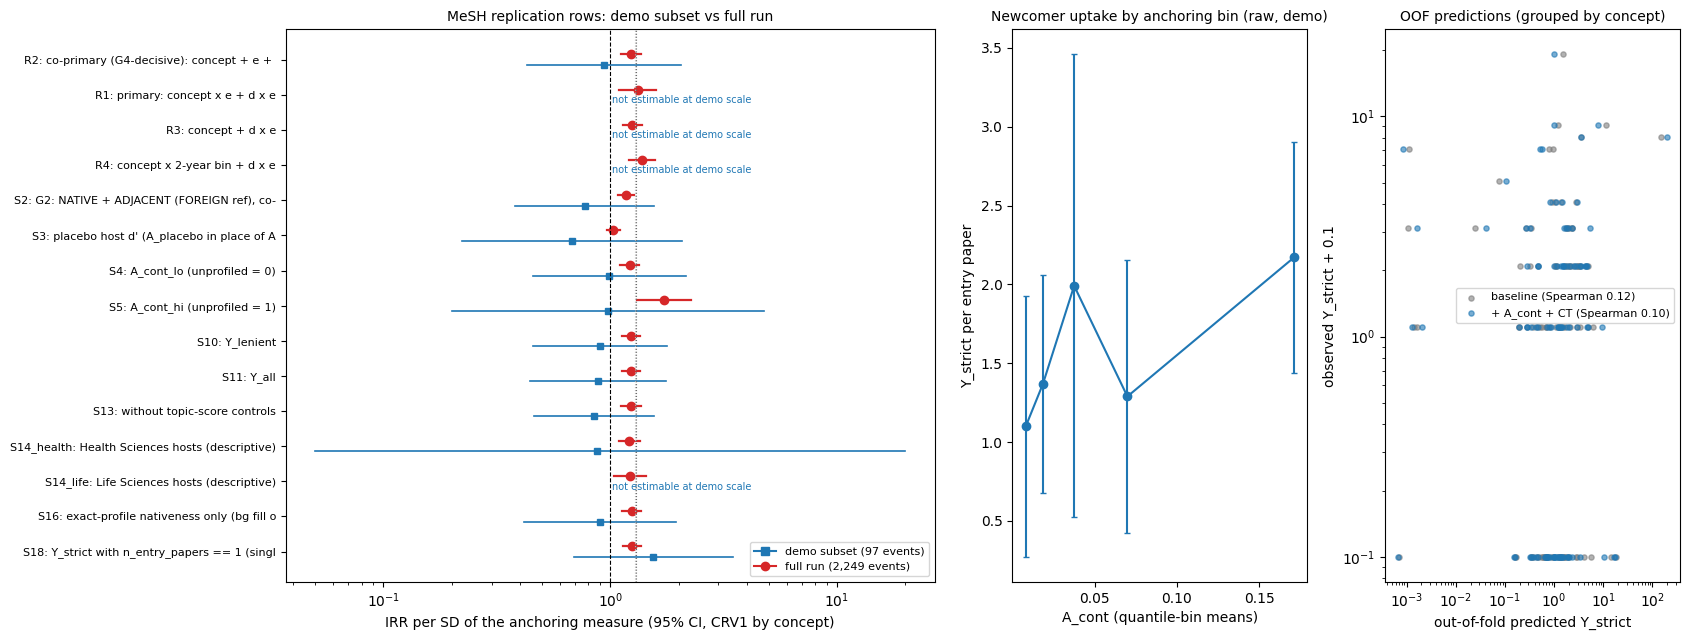

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(17, 6.5), gridspec_kw={"width_ratios": [2.2, 1, 1]})
# (1) forest: demo vs full, IRR per SD (log scale)
ax = axs[0]
keys = [k for k in ["R2", "R1", "R3", "R4", "S2", "S3", "S4", "S5", "S10", "S11", "S13", "S14_health", "S14_life", "S16", "S18"]]
items = []
for key in keys:
    fr = ref["rows"].get(key)
    rr = (R.get(key) or {}).get("row")
    a = (fr or {}).get("var", "A_cont")
    lab = f"{key}: {(R.get(key) or {}).get('label', fr['label'] if fr else '')[:40]}"
    items.append((lab, fr, rr[a] if rr and a in rr else None))
ypos = np.arange(len(items))[::-1]
for yv, (lab, fr, dm) in zip(ypos, items):
    if fr:
        ax.plot(fr["ci"], [yv + 0.15] * 2, color="C3", lw=1.6)
        ax.plot(fr["irr_sd"], yv + 0.15, "o", color="C3", ms=6)
    if dm:
        lo, hi = np.clip(dm["ci_irr_sd"], 0.05, 20)
        ax.plot([lo, hi], [yv - 0.15] * 2, color="C0", lw=1.2)
        ax.plot(np.clip(dm["irr_sd"], 0.05, 20), yv - 0.15, "s", color="C0", ms=5)
    else:
        ax.text(1.02, yv - 0.15, "not estimable at demo scale", fontsize=7, color="C0", va="center")
for v_, c_, l_ in ((MAIN_COPRIMARY["irr_sd"], "0.4", "main co-primary 1.30"), (MAIN_NONPHYS["irr_sd"], "0.7", "main non-physics 1.29")):
    ax.axvline(v_, color=c_, lw=0.8, ls=":")
ax.axvline(1, color="k", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_yticks(ypos)
ax.set_yticklabels([x[0] for x in items], fontsize=8)
ax.plot([], [], "s-", color="C0", label=f"demo subset ({base['n_sample']} events)")
ax.plot([], [], "o-", color="C3", label="full run (2,249 events)")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlabel("IRR per SD of the anchoring measure (95% CI, CRV1 by concept)")
ax.set_title("MeSH replication rows: demo subset vs full run", fontsize=10)
# (2) binned raw uptake (F2 style)
ax = axs[1]
om2 = s.dropna(subset=["A_cont"]).copy()
om2["bin"] = pd.qcut(om2.A_cont, N_BINS, labels=False, duplicates="drop")
g = om2.groupby("bin").apply(lambda x: pd.Series({"A": x.A_cont.mean(), "y": (x.Y_strict / x.n_entry_papers).mean(),
                                                  "se": (x.Y_strict / x.n_entry_papers).std() / np.sqrt(len(x))}),
                             include_groups=False)
ax.errorbar(g.A, g.y, yerr=1.96 * g.se, fmt="o-", color="C0", capsize=2)
ax.set_xlabel("A_cont (quantile-bin means)")
ax.set_ylabel("Y_strict per entry paper")
ax.set_title("Newcomer uptake by anchoring bin (raw, demo)", fontsize=10)
# (3) OOF predictions
ax = axs[2]
ax.scatter(p0, y + 0.1, s=14, alpha=0.6, color="C7", label=f"baseline (Spearman {oos['spearman_baseline']:.2f})")
ax.scatter(p1, y + 0.1, s=14, alpha=0.6, color="C0", label=f"+ A_cont + CT (Spearman {oos['spearman_method']:.2f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("out-of-fold predicted Y_strict")
ax.set_ylabel("observed Y_strict + 0.1")
ax.legend(fontsize=8)
ax.set_title("OOF predictions (grouped by concept)", fontsize=10)
fig.tight_layout()
plt.show()